In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(23)
mu_vec1=np.array([0,0,0])
cov_mat1=np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample=np.random.multivariate_normal(mu_vec1,cov_mat1,20)
df=pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target']=1
mu_vec2=np.array([1,1,1])
cov_mat2=np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample=np.random.multivariate_normal(mu_vec2,cov_mat2,20)
df2=pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df2['target']=0
df = pd.concat([df, df2], ignore_index=True)
df=df.sample(40)

In [3]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [6]:

import plotly.express as px
fig = px.scatter_3d(df, x='feature1', y='feature2', z='feature3', color='target')
fig.show()

In [7]:
# step1: standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.iloc[:,0:3]=scaler.fit_transform(df.iloc[:,0:3])

In [8]:
covariance_mat=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print(covariance_mat)

[[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [9]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_mat)
print('Eigenvalues \n%s' %eigenvalues)

Eigenvalues 
[1.3536065  0.94557084 0.77774573]


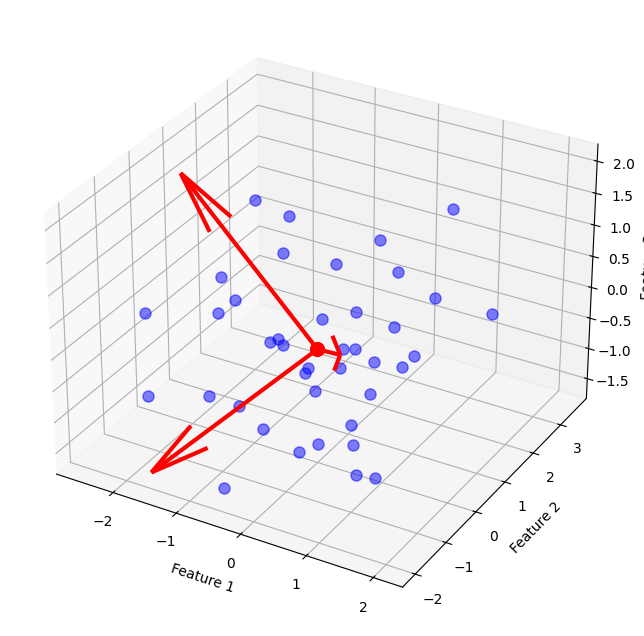

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming df and eigenvectors are already defined in your notebook

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the original data points
ax.plot(df.iloc[:,0], df.iloc[:,1], df.iloc[:,2], 'o', markersize=8, color='blue', alpha=0.5)

# Plot the mean/centroid
mean_x, mean_y, mean_z = df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean()
ax.plot([mean_x], [mean_y], [mean_z], 'o', markersize=10, color='red')

# Plot the eigenvectors using ax.quiver instead of custom FancyArrowPatch
for v in eigenvectors.T:
    ax.quiver(mean_x, mean_y, mean_z, v[0], v[1], v[2], 
              length=3.0, # Scale the arrow length as needed
              normalize=False, 
              color='red', 
              linewidth=3)

# Set labels for clarity
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

plt.show()


In [15]:
pc=eigenvectors[0:2,:]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [18]:
transformed_data=np.dot(pc,df.iloc[:,0:3].T)
new_df=pd.DataFrame(transformed_data.T,columns=['PC1','PC2'])
new_df['target']=df['target']
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,1
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [19]:
#plot new_df
import plotly.express as px
fig = px.scatter(new_df, x='PC1', y='PC2', color='target')
fig.show()